VISUALIZZARE LO SPAZIO LATENTE DEL VAE

Visualizzare lo spazio latente del VAE significa vedere come l'Encoder ha organizzato i idati nello spazio z.
Vediamo il pensiero di una rete neurale.

- Scatter plot 2D: mappare i dati nel piano latente, schiacciando la complessità del mondo in un piano che i nostri occhi possano comprendere
- Analisi della Continuità per scoprire il segresto della vicinanza semantica tra le classi
- Confronto tra VAE e AE classico.

Mappare i dati in 2D

Mappiamo i dati in 2 D perchè la nostra mente la comprende facilmente.
Se il VAE ha latent_dim=2, possiamo visualizzarlo direttamente. Se ha dimensioni maggiori di 3 dobbiamo ridurlo a 2 dimensioni, forse 3, ma non di più, per essere comprensibile all'occhio umano.
Utilizzamo un bottleneck di dimensione 2 (va bene anche PCA) per forzare l'encoder a etrarre solo le due coordinate fondamentali per descrivere l'intero dataset.
Questo due coordinate sono le coordinate dello spazio latente.

La cosa interessante è colorare i punti in base alla classe di appartenenza (se presente).
In questo modo dovremmo accorgerci che l'Encoder ha imparato a posizionare immagini semanticamente simili in zone vicine.
Se così è il modello ha scoperto strutture visive prensenti nei dati.

Quanto si vuole visualizzare lo spazio latente si usa mu, non uno z casualmente campionato.
per una stessa immagine mu è il punto centrale, mentre z=mu+eps*std

Scatter Plot e Classi
Le geografica dell'informazione
Ogni punto del grafico rappresenta un'immagine (compressa in 2 numeri) del test set compressa dall'encoder in un vettore bidimensionale.
La magia avviene quando coloriamo i singoli punti.
Colorado i punti in base alle etichette originali, possiamo osservare come il modello raggruppa concetti simili.
I colori non saranno sparsi a caso, ma la rete ha creato dei quartieri specifici.
La separazione netta tra i colori indica quanto bene il modello distingue le diverse feature dei dati. Il modello ha imparato a distinguere i tratti fondamentali.
La forma della nuvola di punti riflette la regolarizzazione gaussiana che abbiamo impostato durante l'addestramento.
Se le nuvole di punti sono ben definite, significa che la regolarizzazione gaussiana ha lavorato bene, la rete non si è limitata a memorizzare ma ha organizzato le informazioni in modo logico.
Se i punti sono sovrapposti, sparsi e non hanno una struttura, qualcosa è andato storto nella fase di addestramento.

Ma oltra alla posizione, cosa ci dicono questi assi sulle dinamiche della proiezione?

Dinamiche di Proiezione.
gli assi x e y non hanno un significato fisico immediato (es altezza o larghezza), rappresentano invece dimensioni astratte di variazione.
Le zone dove i colori si mescolano, stiamo osservando la frontiera dellì'incertezza. Sono campioni che hanno caratteristiche ambigue, tratti comuni a più classi.
Ma la cosa interessante è la generazione in tempo reale. Se movessimo un cursore su questo piano, vediamo il decoder che trasfomra quati numeri in immagini istantanee.

Cosa succese se due dimensioni non bastano per catturare tutta la complessità?

Oltre il Piano 2D
Rappresentazioni ad alta dimensione.
In produzione  usiamo spesso centinaia di dimensioni latente, ma la visualizzazione 2D rimane un test diagnostico fondamentale.
In questi casi non possiamo utilizzare uno Scatter Plot semplice.
Per visualizzare spazi latenti più complessi ricorriamo a tecniche di riduzione della dimensionalità come t-SNE o UMAP sui vettori.
Pensa a queste tecniche come a delle lenti di ingrandimento che ci permettono di vedere la struttura di un oggetti multidimensionale, proiettandone l'ombra su un foglio 2D.
Anche se perdiamo qualche dettaglio la topologia, ovvero chi è vicino a chi, rimane intatta, ed è il nostro test diagnostico principale.

Analisi della Continuità
Il miracolo della vicinanza semantica.
Nel VAE, classi visivamente simili devono trovarsi vicine nello spazio latente per garantire che il modello abbia capito la struttura del dato. La vicinanza non è causale ma semantica.
Questo proprietà emerge naturalmente grazie alla sovrapposizione delle nuvole di probabilità gasussiane creare durante il training.
Poichè un immagine non è un punto, ma una nuvola di probabilità, queste nuvole devono necessariamente sfumare l'una nell'altra.
E' questa sovrapposizione controllata, che garantisce che il modello ha capito come il mondo è strutturato.

Esempio concetro 
Vicinanza Semantica.
Perchè l'uno somiglia al sette
Numeri come 1 e 7 o 3 e 8 condividono tratti morfologici che la rete impara a mappare in zone contigue.
1 e 7 morfologicamente condividono un tratto verticale.
Lo scatter plot mostra questi cluster quasi a contatto, evidenziando la transizione fluida tra i tratti.
La continuità permette di interpolare tra due classi senza passare per immagni prive di senso visivo.
La regolarizzazione impedisce alla rete di creare isole isolate per ogni singola immagine del dataset
La rete impara che per trasformare un 1 in un 7 basta aggiungere una piccola barra orrizonatale in alto.
Questa transizione fluida (da 1 a 7) è la prova che non ci sono bariere artificiale nello spazio.
Possiamo muoverci da un identità ad un altra senza mai passare per il nulla cosmico, ogni tappa produce un immagine sensata.

Geometria dello Spazio
Muovendoci su una retta tra due cluster diverse, osserviamo il morphing fluido dei tratti grafici del dato (interpolazione lineare).
Il centro di gravità di ogni cluster rappresenta il 'campione ideale' o più rappresentativa di quella specifica categoria (centroidi di Classe)
La mancanza di transizioni a scatti è la prova empirica che lo spazio è liscio e ben regolarizzato e questo grazie al Reparameterization Trick che sta funzionando correttamente.

Questo ci porta ad una proprietà che distintue i VAE da ogni altro modello, la densità

La Densità Latente
Uno spazio senza vuoti.
Grazie al termine KL, il nostro spazio latente è denso. 
Ogni punto dello spazio latente ha un'alta probabilità di generare qualcosa di verosimile all'occhio umano.
In un AE classico lo spazio è come un deserto con pochi punti isolati.
Nel VAE non esistono 'terre di nessuno' dove il decoder produce puro rumore, a differenza di quanto accade nei modelli non variazionali.

Per capire questa differenza dobbiamo mettere i due modelli faccia a faccia.

Confronto Strutturale: VAE vs AE
Densità contro Discontinuità
Visualizzare i due spazi latenti affiancati è il modo più rapido per comprendere la reale superiorità generativa del VAE.
Mentre l'Autoencoder classico si comporta come un archivista disordinato (che lancia doucmenti e scatole lontano tra loro), il VAE agisce come un cartografo preciso e metodico, organizza tutto in un contenuto compatto e connesso.
La differenza non è solo estetica, è funzionale.

Buchi contro Massa
L'effetto della regolarizzazione
L'AE mostra cluster frammentati e distanti, con enormi zone di vuoto informativo tra di essi.
AE -> tente isole
Il VAE mostra una distribuzione compatta e densa, solitamente centrata nell'origine degli assi.
VAE -> un unico continente
Campionare fuori dai cluster nell'AE produce immagini inconsistenti e rumore digitale.
Campionare tra i cluster nel VAE produce transizioni sensate che mescolano le caratteristiche delle classi.

Come possiamo usare queste immagini per capire se il nostro addestramento sta andando bene.

Diagnostica del Training
Visualizzare lo spazio lantente è la nostra migliore tecnica diagnostica.
Se tutti i punti dello scatter plot collassano nello zero, significa che la KL ha dominato sulla ricostruzione (posterir collapse). La rete ha smesso di imparare dettagli.
Se i cluster dell'AE sono tropppo piccoli, puntiformi e isolati, la rete ha solo memorizzato i dati senza imparare la struttura (overfitting dell'AE).
La capacità di gestire input nuovi e rumorosi dipende direttamente dalla densità latente raggiunta (capacità generativa).
La densità latente è il termometro che ci dice quanto il nostro modlelo è pronto per affrontare dati nuovi e rumorosi.

Ma c'è un parametro magico che controlla proprio questa densità

L'Impatto del Coefficiente Beta
Regolare la compattezza dello spazio
Beta è il nostro cursore della pressione statistica
Variando il peso del termine KL, possiamo forzare i cluster a essere più o meno vicini tra loro.
Un Beta elevato crea cluster fusi e densi, mentre un Beta basso produce uno spzio simile all'AE ma meno generativo (spazio più nitido con meno zone sovrapposte).
Beta > 1 -> Maggiore Sovrapposizione

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.03MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 320kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.81MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.04MB/s]


Avvio degli esperimenti di confronto tra Autoencoder e VAE...
Addestramento in corso: Autoencoder (Senza KL)...
Addestramento in corso: VAE (Beta=1)...
Addestramento in corso: VAE (Beta=3)...
Addestramento in corso: VAE (Beta=10)...


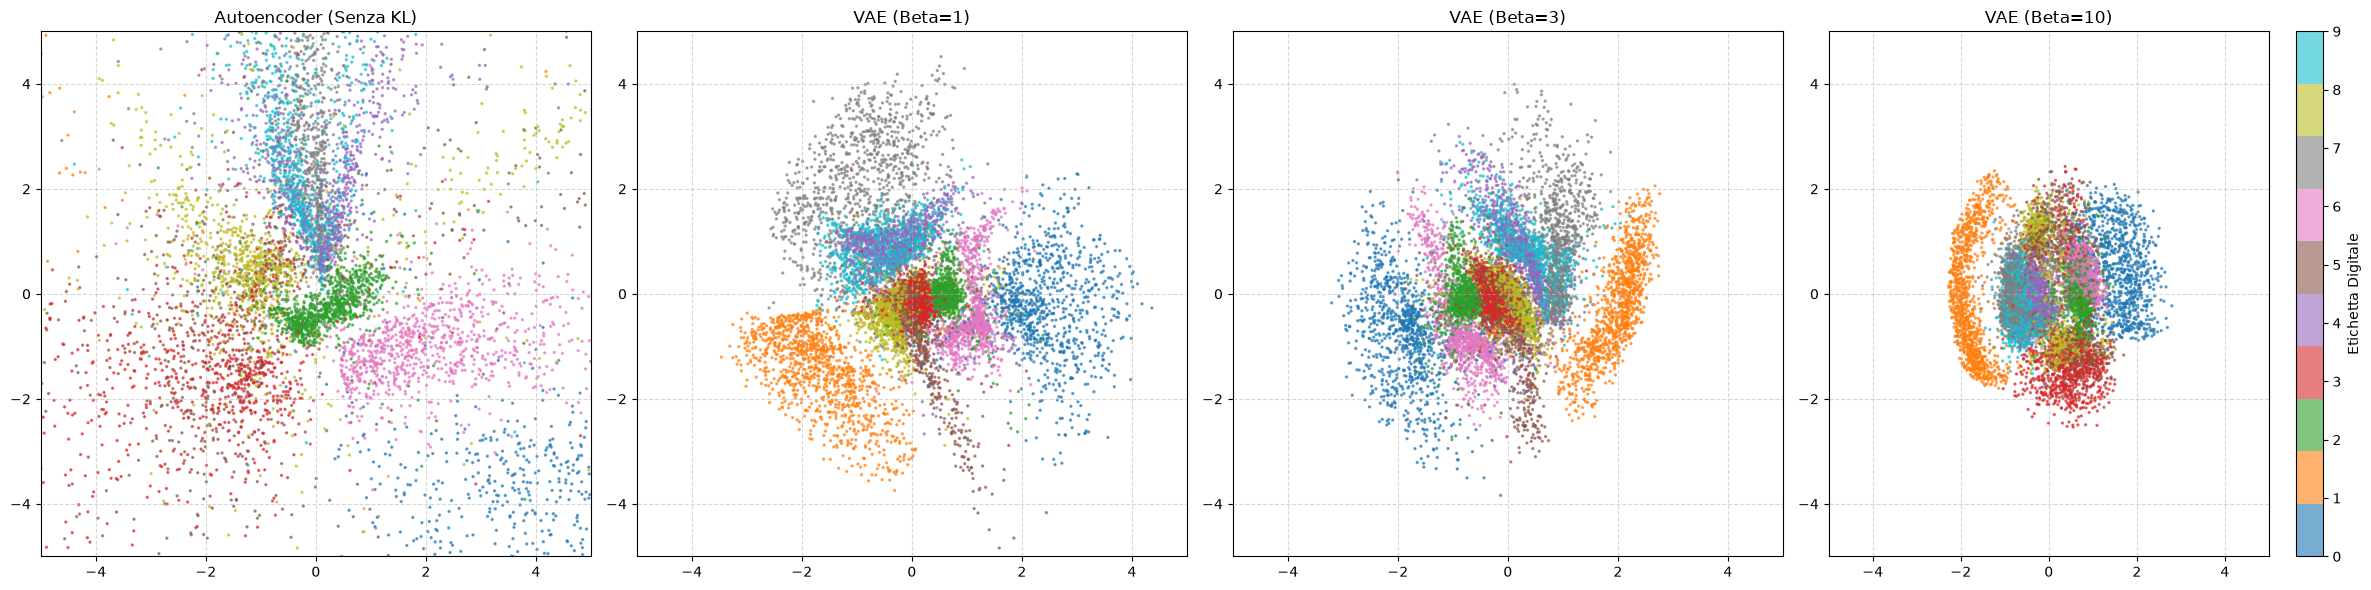

: 

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

# Configurazione dei parametri principali per l'esecuzione del modello
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 128    # Numero di campioni analizzati per ogni iterazione di gradient descent
LR = 1e-3           # Learning Rate: velocità di apprendimento dell'ottimizzatore
EPOCHS = 5         # Numero di cicli completi attraverso l'intero set di dati
LATENT_DIM = 2     # Dimensione dello spazio latente (2D per permettere la visualizzazione diretta)

class LatentModel(nn.Module):
    """
    Classe che implementa sia un Autoencoder (AE) che un Variational Autoencoder (VAE).
    La struttura è composta da un Encoder, un collo di bottiglia (Bottleneck) e un Decoder.
    """
    def __init__(self, is_vae=True):
        super().__init__()
        self.is_vae = is_vae
        
        # L'Encoder riduce gradualmente la dimensione dell'immagine (28x28 = 784 pixel)
        # a una rappresentazione compressa più astratta.
        self.encoder_fc = nn.Sequential(
            nn.Linear(784, 400),
            nn.ReLU(),
            nn.Linear(400, 200),
            nn.ReLU()
        )
        
        # Definizione dello spazio latente. 
        # In un VAE, l'encoder non produce un singolo punto, ma i parametri di una distribuzione:
        # mu rappresenta la media, logvar il logaritmo della varianza.
        self.fc_mu = nn.Linear(200, LATENT_DIM)
        self.fc_logvar = nn.Linear(200, LATENT_DIM)
        
        # Il Decoder riceve un punto dallo spazio latente e cerca di ricostruire l'immagine originale.
        # L'obiettivo è ripristinare la dimensione 784 partendo da LATENT_DIM.
        self.decoder = nn.Sequential(
            nn.Linear(LATENT_DIM, 200),
            nn.ReLU(),
            nn.Linear(200, 400),
            nn.ReLU(),
            nn.Linear(400, 784),
            nn.Sigmoid() # Sigmoid garantisce che i pixel siano nell'intervallo [0, 1]
        )

    def reparameterize(self, mu, logvar):
        """
        Applica il 'Reparameterization Trick' fondamentale per l'addestramento dei VAE.
        Permette la backpropagation attraverso un campionamento stocastico.
        Se il modello è un AE standard, restituisce direttamente la media senza campionamento.
        """
        if not self.is_vae: 
            return mu
            
        # Calcoliamo la deviazione standard dalla varianza logaritmica
        std = torch.exp(0.5 * logvar)
        # Generiamo un rumore casuale epsilon da una distribuzione normale standard
        eps = torch.randn_like(std)
        # Il punto latente z è calcolato come: media + rumore * deviazione_standard
        return mu + eps * std

    def forward(self, x):
        """
        Definisce il flusso dei dati: Immagine -> Encoder -> Spazio Latente -> Decoder -> Ricostruzione.
        """
        # Flatten dell'immagine da (1, 28, 28) a (784)
        h = self.encoder_fc(x.view(-1, 784))
        
        # Calcolo dei parametri della distribuzione latente
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # Generazione del vettore latente z tramite riparametrizzazione
        z = self.reparameterize(mu, logvar)
        
        # Restituisce l'immagine ricostruita insieme ai parametri latenti per il calcolo della loss
        return self.decoder(z), mu, logvar

def loss_fn(recon_x, x, mu, logvar, beta, is_vae):
    """
    Funzione di perdita che guida l'apprendimento del modello.
    In un VAE, è composta da due termini: ricostruzione e regolarizzazione (KL Divergence).
    """
    # L'errore di ricostruzione (Binary Cross Entropy) misura quanto la copia sia simile all'originale.
    # Si somma l'errore su tutti i 784 pixel per ogni immagine del batch.
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 784), reduction='sum')
    
    # Se è un Autoencoder standard, usiamo solo l'errore di ricostruzione.
    if not is_vae: 
        return BCE
    
    # La Divergenza di Kullback-Leibler (KLD) forza lo spazio latente a seguire una distribuzione normale standard.
    # Questo termine "ordina" lo spazio latente, creando cluster coerenti e aree continue.
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    
    # La perdita totale è il bilanciamento tra fedeltà (BCE) e struttura dello spazio (KLD).
    # Il parametro beta controlla quanto peso dare alla regolarizzazione KL.
    return BCE + beta * KLD

# Caricamento del dataset MNIST (cifre scritte a mano)
transform = transforms.Compose([transforms.ToTensor()])
train_loader = DataLoader(datasets.MNIST('.', train=True, download=True, transform=transform), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(datasets.MNIST('.', train=False, transform=transform), batch_size=BATCH_SIZE, shuffle=False)

def run_experiment(is_vae, beta):
    """
    Funzione di coordinamento per l'addestramento e la successiva estrazione dei dati latenti.
    Interagisce con la classe LatentModel per il training e la funzione loss_fn per l'ottimizzazione.
    """
    model = LatentModel(is_vae=is_vae).to(device)
    optimizer = optim.Adam(model.parameters(), lr=LR)
    
    for epoch in range(EPOCHS):
        model.train()
        for data, _ in train_loader:
            data = data.to(device)
            optimizer.zero_grad() # Reset dei gradienti per la nuova iterazione
            
            # Passaggio avanti (forward pass)
            recon, mu, logvar = model(data)
            
            # Calcolo della perdita globale
            loss = loss_fn(recon, data, mu, logvar, beta, is_vae)
            
            # Passaggio all'indietro (backpropagation)
            loss.backward()
            optimizer.step()
            
    # Fase di valutazione: estraiamo le coordinate dei punti nello spazio latente
    model.eval()
    z_points, labels = [], []
    with torch.no_grad():
        for data, target in test_loader:
            data = data.to(device)
            h = model.encoder_fc(data.view(-1, 784))
            # Utilizziamo la media (mu) come punto rappresentativo per la visualizzazione
            z = model.fc_mu(h) 
            z_points.append(z.cpu())
            labels.append(target) # Conserviamo l'etichetta originale (0-9) per colorare i punti
            
    return torch.cat(z_points), torch.cat(labels)

# Main script: esegue il confronto tra diverse configurazioni di modelli
print("Avvio degli esperimenti di confronto tra Autoencoder e VAE...")

# Definizione dei casi di test: tipo di modello, valore di beta e etichetta per il grafico
configs = [
    (False, 0, "Autoencoder (Senza KL)"),
    (True, 1, "VAE (Beta=1)"),
    (True, 3, "VAE (Beta=3)"),
    (True, 10, "VAE (Beta=10)")
]

results = []
for is_vae, beta, title in configs:
    print(f"Addestramento in corso: {title}...")
    z, y = run_experiment(is_vae, beta)
    results.append((z, y, title))

# Creazione della visualizzazione finale per confrontare gli spazi latenti
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
for i, (z, y, title) in enumerate(results):
    # Ogni cifra (0-9) è rappresentata da un colore diverso nello scatter plot
    sc = axes[i].scatter(z[:, 0], z[:, 1], c=y, cmap='tab10', s=2, alpha=0.6)
    axes[i].set_title(title)
    # Scale fisse per rendere il confronto visivo oggettivo tra i grafici
    axes[i].set_xlim(-5, 5)
    axes[i].set_ylim(-5, 5) 
    axes[i].grid(True, linestyle='--', alpha=0.5)

# Aggiunta di una barra dei colori per indicare a quale cifra corrisponde ogni colore
plt.colorbar(sc, ax=axes[-1], label='Etichetta Digitale')
plt.tight_layout()
plt.show()